### GMM model draft

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
# Load the merged dataset
df = pd.read_csv("Filtered dataset/iSUPER_Weather_Underground_merged_2025.csv")

# Parse timestamp if needed
#df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)

display(df.head())
print(df["Dew/Temp fog?"].value_counts())
df["RH fog?"].value_counts()


,timestamp_utc,rh_sensor,temp_sensor,pm1,pm25,pm10,Temperature_C,Dew_Point_C,Humidity_%,Speed_kmh,Pressure_hPa,Precip_Rate_mm,Precip_Accum_mm,Wind,Dew/Temp fog?,RH fog?
0,2025-08-17 00:00:00+00:00,48.76,27.10,14.38,14.51,14.51,24.06,17.61,67.0,15.12,1016.59,0.0,0.0,SSW,0.0,0.0
1,2025-08-17 00:05:00+00:00,49.02,27.00,13.94,14.24,14.24,23.89,17.56,68.0,15.45,1016.93,0.0,0.0,SSW,0.0,0.0
2,2025-08-17 00:10:00+00:00,49.20,26.90,13.75,14.00,14.00,23.78,17.72,69.0,15.29,1016.93,0.0,0.0,SSW,0.0,0.0
3,2025-08-17 00:15:00+00:00,49.40,26.82,13.68,13.95,16.26,23.83,17.22,67.0,18.34,1016.93,0.0,0.0,SSW,0.0,0.0
4,2025-08-17 00:20:00+00:00,49.50,26.76,12.60,12.73,12.73,24.06,17.33,66.0,14.32,1016.59,0.0,0.0,SSW,0.0,0.0


Dew/Temp fog?
0.0    15645
1.0     6272
Name: count, dtype: int64


RH fog?
0.0    20147
1.0     1792
Name: count, dtype: int64

In [62]:
# Build fog label if either flags are true
df["fog_label"] = (
    (df["Dew/Temp fog?"] > 0) | (df["RH fog?"] > 0)
).astype(int)

print(df["fog_label"].value_counts())
df.sample(5)

fog_label
0    19338
1     6294
Name: count, dtype: int64


,timestamp_utc,rh_sensor,temp_sensor,pm1,pm25,pm10,Temperature_C,Dew_Point_C,Humidity_%,Speed_kmh,Pressure_hPa,Precip_Rate_mm,Precip_Accum_mm,Wind,Dew/Temp fog?,RH fog?,fog_label
16951,2025-10-14 20:35:00+00:00,85.66,14.40,1.77,3.44,5.11,12.50,12.28,99.0,3.86,1017.27,1.78,8.38,ENE,1.0,1.0,1
18717,2025-10-20 23:45:00+00:00,68.60,15.50,3.37,3.69,3.69,14.22,11.17,82.0,10.46,1005.76,0.00,13.72,SW,0.0,0.0,0
10672,2025-09-23 01:20:00+00:00,62.98,19.68,3.01,3.74,8.40,17.78,14.06,79.0,14.32,1016.26,0.00,0.00,SSW,0.0,0.0,0
934,2025-08-20 05:50:00+00:00,60.96,18.70,2.46,2.88,5.18,16.78,12.78,77.0,6.76,1022.01,0.00,0.00,South,0.0,0.0,0
24633,2025-11-10 12:45:00+00:00,86.68,13.70,3.98,4.87,4.97,11.83,11.67,99.0,1.93,1005.42,0.00,0.51,East,1.0,1.0,1


In [63]:
# Choose features for the model
feature_cols = [
    "rh_sensor",
    "temp_sensor",
    "pm1",
    "pm25",
    "pm10",
    "Temperature_C",
    "Dew_Point_C",
    "Humidity_%",
    "Speed_kmh",
    "Pressure_hPa",
    "Precip_Rate_mm",
    "Precip_Accum_mm",
]

# Drop rows with missing values in these features
X_raw = df[feature_cols].dropna()

# Align labels with the filtered rows
y = df.loc[X_raw.index, "fog_label"]

print(X_raw.shape, y.shape)


(21835, 12) (21835,)


In [64]:
# Normalize to [0, 1]
scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)

X[:1]


array([[0.43370607, 0.69713656, 0.08881084, 0.08914729, 0.08914729,
        0.72951598, 0.79623514, 0.50769231, 0.39653816, 0.65535821,
        0.        , 0.        ]])

### GMM train and test

In [65]:
# Train final GMM with 2 components (fog vs no fog), k=2
gmm_fog = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)
gmm_fog.fit(X)

# Hard cluster assignments
clusters = gmm_fog.predict(X)
np.unique(clusters, return_counts=True)


(array([0, 1], dtype=int64), array([ 4135, 17700], dtype=int64))

In [73]:
# Decide which cluster is the "fog" by looking at the average fog_label in each cluster
cluster0_mean = y[clusters == 0].mean()
cluster1_mean = y[clusters == 1].mean()
print("Cluster 0 mean fog_label:", cluster0_mean)
print("Cluster 1 mean fog_label:", cluster1_mean)

# Cluster with higher fog_label frequency = fog cluster
fog_cluster = 0 if cluster0_mean > cluster1_mean else 1
print("Chosen cluster for fog is cluster", fog_cluster) # fog_cluster


Cluster 0 mean fog_label: 0.6669891172914147
Cluster 1 mean fog_label: 0.19830508474576272
Chosen cluster for fog is cluster 0


### Feature visualization

C:\Users\USER\AppData\Local\Temp\ipykernel_64628\3327026622.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_64628\3327026622.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


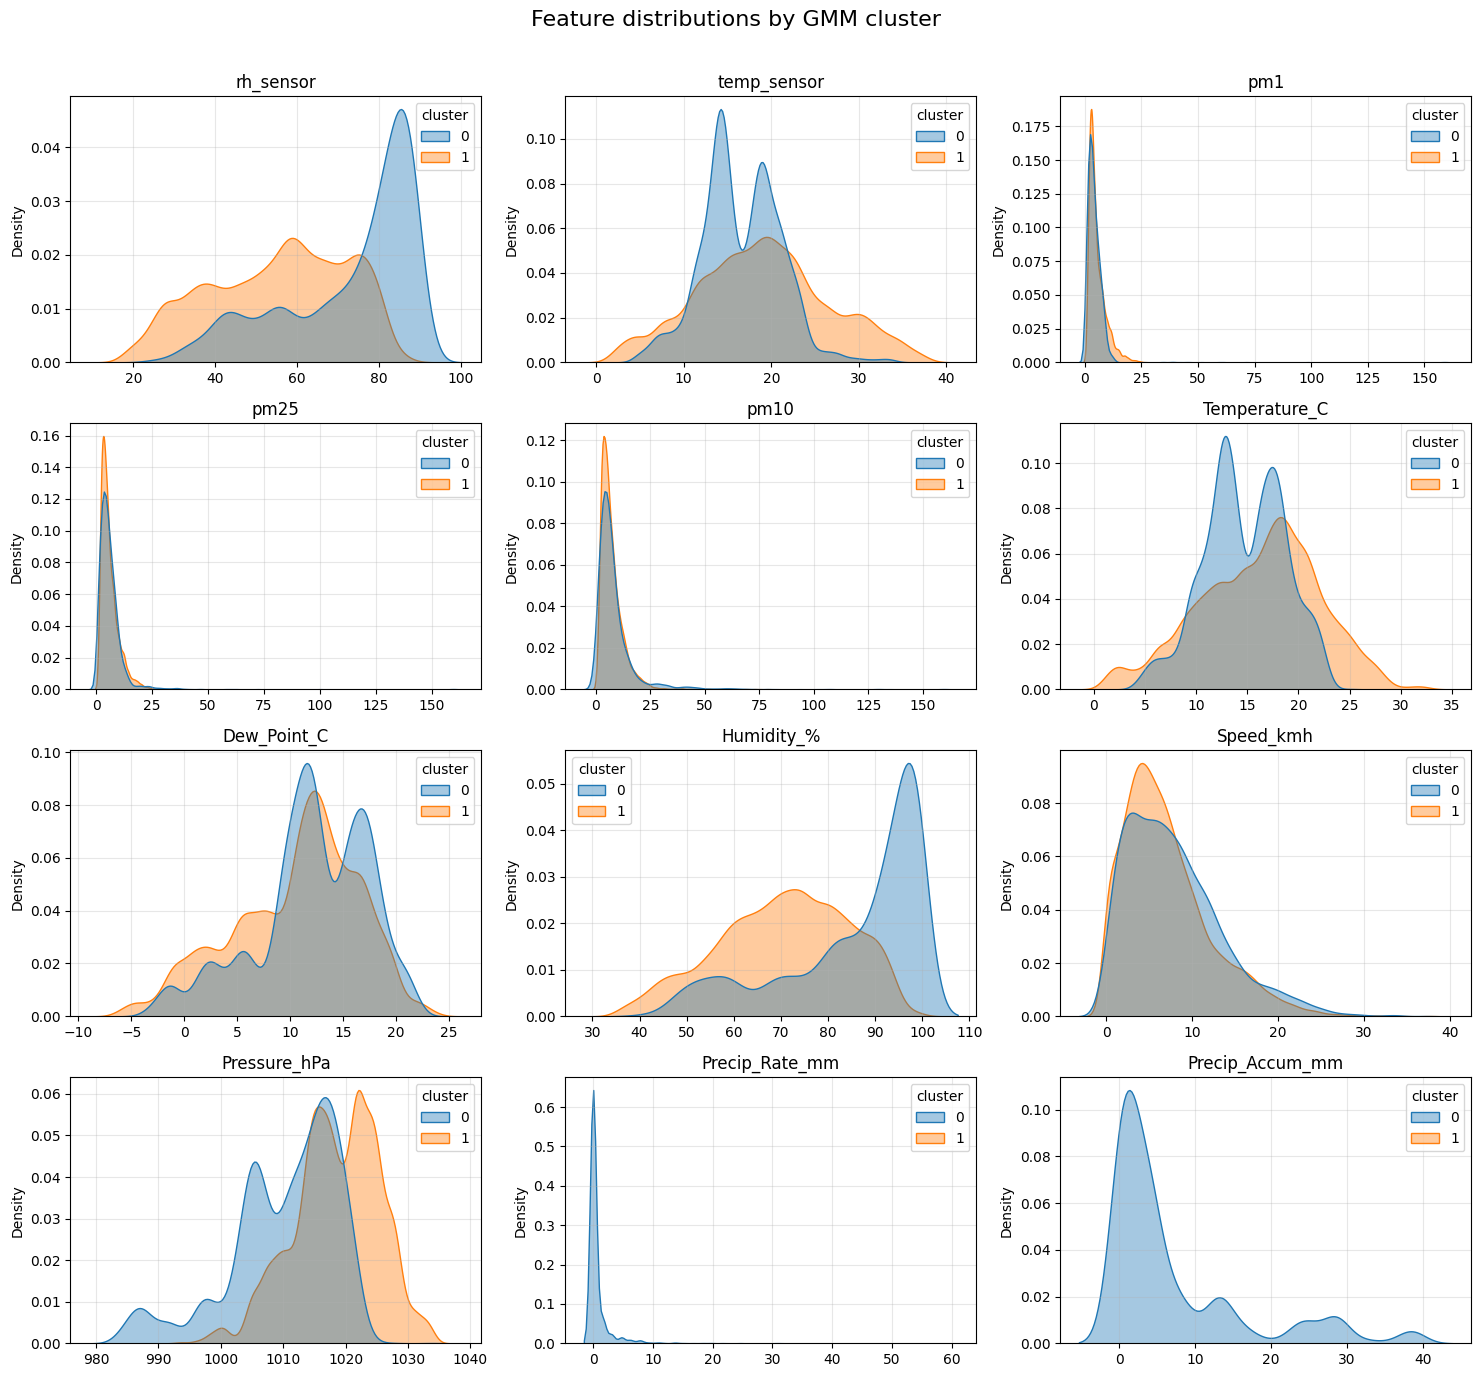

In [67]:
# DataFrame tying features to cluster labels
df_feat_vis = X_raw[feature_cols].copy()
df_feat_vis["cluster"] = clusters

n_features = len(feature_cols)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    ax = axes[i]
    sns.kdeplot(
        data=df_feat_vis,
        x=feat,
        hue="cluster",
        common_norm=False,
        fill=True,
        alpha=0.4,
        ax=ax,
    )
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.grid(True, alpha=0.3)

# Hide any unused subplots if n_features is not a multiple of n_cols
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature distributions by GMM cluster", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

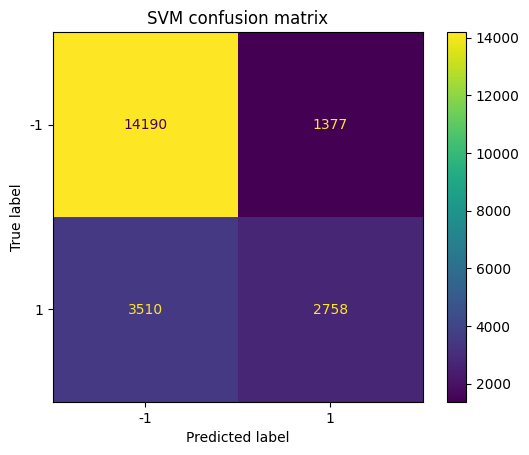

              precision    recall  f1-score   support

           0      0.802     0.912     0.853     15567
           1      0.667     0.440     0.530      6268

    accuracy                          0.776     21835
   macro avg      0.734     0.676     0.692     21835
weighted avg      0.763     0.776     0.760     21835



In [68]:
# Predicted fog / no-fog from GMM
y_pred = (clusters == fog_cluster).astype(int)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 1])
disp.plot()
plt.title(f"SVM confusion matrix")
plt.show()

print(classification_report(y, y_pred, digits=3))


### More Visualization

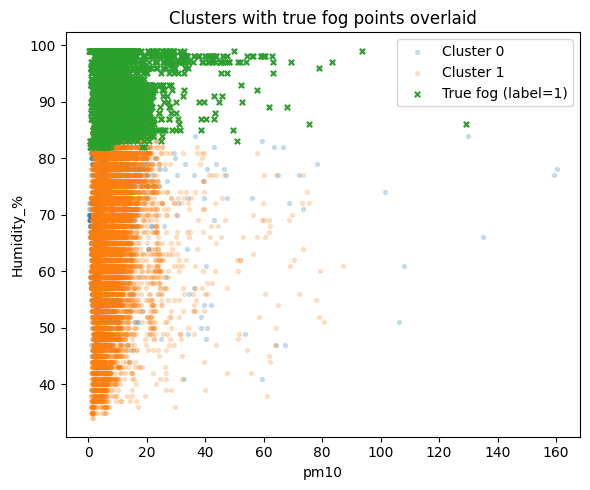

In [69]:
fig, ax = plt.subplots(figsize=(6, 5))

# background: all points by cluster
for k in np.unique(clusters):
    mask = clusters == k
    ax.scatter(
        x1[mask],
        x2[mask],
        s=8,
        alpha=0.2,
        label=f"Cluster {k}"
    )

# overlay: true fog points
fog_mask = (y == 1)
ax.scatter(
    x1[fog_mask],
    x2[fog_mask],
    s=15,
    marker="x",
    label="True fog (label=1)"
)

ax.set_xlabel(f1)
ax.set_ylabel(f2)
ax.set_title("Clusters with true fog points overlaid")
ax.legend()
plt.tight_layout()
plt.show()


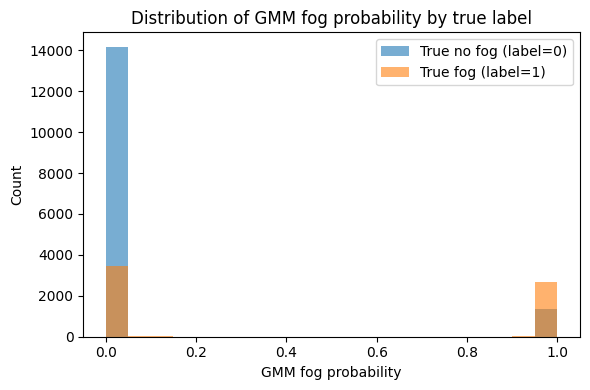

In [71]:
fog_proba_series = df.loc[X_raw.index, "gmm_fog_proba"]
label_series = y  # from earlier

fig, ax = plt.subplots(figsize=(6, 4))

# non-fog
ax.hist(
    fog_proba_series[label_series == 0],
    bins=20,
    alpha=0.6,
    label="True no fog (label=0)"
)

# fog
ax.hist(
    fog_proba_series[label_series == 1],
    bins=20,
    alpha=0.6,
    label="True fog (label=1)"
)

ax.set_xlabel("GMM fog probability")
ax.set_ylabel("Count")
ax.set_title("Distribution of GMM fog probability by true label")
ax.legend()
plt.tight_layout()
plt.show()


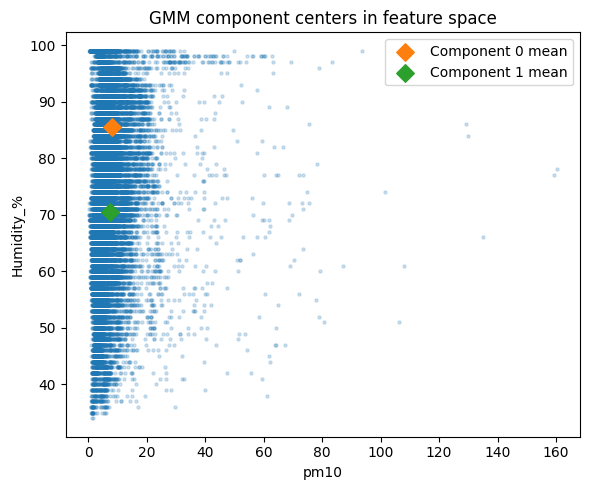

In [72]:
# Get component means in scaled space and map them back to original for the chosen two features
f1_idx = feature_cols.index(f1)
f2_idx = feature_cols.index(f2)

means_scaled = gmm_fog.means_
# approximate inverse scaling for 2 features
min_vals = X_raw.min(axis=0).values
max_vals = X_raw.max(axis=0).values

means_orig_f1 = means_scaled[:, f1_idx] * (max_vals[f1_idx] - min_vals[f1_idx]) + min_vals[f1_idx]
means_orig_f2 = means_scaled[:, f2_idx] * (max_vals[f2_idx] - min_vals[f2_idx]) + min_vals[f2_idx]

fig, ax = plt.subplots(figsize=(6, 5))

# data
ax.scatter(x1, x2, s=5, alpha=0.2)

# component centers
for k in range(gmm_fog.n_components):
    ax.scatter(
        means_orig_f1[k],
        means_orig_f2[k],
        s=80,
        marker="D",
        label=f"Component {k} mean"
    )

ax.set_xlabel(f1)
ax.set_ylabel(f2)
ax.set_title("GMM component centers in feature space")
ax.legend()
plt.tight_layout()
plt.show()
